# Chapter 14.1 PCA: 분산을 최대로 보존하는 축 찾기 — 실습 노트북

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SuminHan/book-ml/blob/main/notebooks/ml1/chapter14_1_pca.ipynb)

책 본문: [14.1 PCA: 분산을 최대로 보존하는 축 찾기](https://smhanlab.com/book-ml/kor/ml1/chapter14/1.html)

이 노트북은 책 14.1절의 PCA 코드를 그대로 실행하고, (1) 4개 점 장난감 데이터에서
**고유값/주성분을 numpy로 직접 구해** 본문의 "손으로 한 번" 계산을 재현하고,
(2) 4차원 붓꽃 데이터를 2차원으로 압축해 **얼마나 많은 정보가 남는지** 확인하고,
(3) **스케일링(표준화) 없이 PCA를 돌리면** 주성분의 방향이 어떻게 달라지는지 보여줍니다.


## 1. 장난감 데이터: 4개 점에서 PCA (본문 "손으로 한 번" 재현)

본문과 동일한 4개 점 \((−2,−1),(−1,−2),(2,1),(1,2)\) — 의도적으로
**원점 중심**이라 중심화 단계가 사실상 사라지고, 계산을 단순하게 잡았다.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

P = np.array([[-2, -1], [-1, -2], [2, 1], [1, 2]], dtype=float)  # 원점 중심
Xc = P - P.mean(axis=0)          # 중심화 (여기서 mean은 (0,0))
cov = (Xc.T @ Xc) / len(Xc)       # 공분산 행렬
ev, evec = np.linalg.eigh(cov)    # 고유값, 고유벡터(단위길이)
o = np.argsort(ev)[::-1]          # 고유값 내림차순
ev, evec = ev[o], evec[:, o]

print("공분산 행렬:", cov.tolist())
print("고유값 (각 주성분의 분산):", ev, "  비율:", (ev/ev.sum()).round(4).tolist())
v1 = evec[:, 0]
print("PC1 방향(고유벡터):", (v1/np.linalg.norm(v1)).round(4).tolist())


공분산 행렬: [[2.5, 2.0], [2.0, 2.5]]
고유값 (각 주성분의 분산): [4.5 0.5]   비율: [0.9, 0.1]
PC1 방향(고유벡터): [0.7071, 0.7071]


본문의 손계산: 공분산 \(\begin{pmatrix}2.5&2.0\\2.0&2.5\end{pmatrix}\),
고유값 \(\lambda_1=4.5,\ \lambda_2=0.5\), PC1은 45도 대각선
\((1,1)/\sqrt2\) — 위 수치와 정확히 일치한다. \(\lambda_1+\lambda_2=5.0\)
이 전체 분산(trace)과 같음에 주의.


In [2]:
# (1) PC1에 투영 -> 분산 = lambda1 임을 확인
proj = Xc @ v1
print("PC1에 투영한 좌표:", proj.round(3))
print("투영된 분산:", round(proj.var(ddof=0), 4), "  (고유값 lambda1 =", ev[0], ")")

# (2) 주성분 1개만 남기고 재구성 -> 평균 제곱오차 = lambda2 임을 확인
Xrec = (proj[:, None] * v1[None, :]) + P.mean(axis=0)
err = np.linalg.norm(Xrec - P, axis=1)
print("점별 재구성 오차:", err.round(3), "  (모두 1/sqrt2 = 0.707)")
print("평균 제곱오차:", round((err**2).mean(), 4), "  (버린 고유값 lambda2 =", ev[1], ")")


PC1에 투영한 좌표: [-2.121 -2.121  2.121  2.121]
투영된 분산: 4.5   (고유값 lambda1 = 4.5 )
점별 재구성 오차: [0.707 0.707 0.707 0.707]   (모두 1/sqrt2 = 0.707)
평균 제곱오차: 0.5   (버린 고유값 lambda2 = 0.5 )


**재구성 오차의 평균 제곱 = 버린 주성분의 고유값(\(\lambda_2\))과 정확히
같다** — 본문 6단계의 핵심 성질 "상위 성분만 남길 때 잃는 정보량 = 버린
성분들의 고유값의 합"을 수치로 확인한 것이다.


In [3]:
# (3) 1차원으로 줄인 값에 k-means(k=2)를 돌리면 두 그룹이 완벽히 갈라진다
def kmeans1d(z, iters=50):
    c = np.array([z.min(), z.max()])
    for _ in range(iters):
        lab = (z < (c[0] + c[1]) / 2).astype(int)
        nc = np.array([z[lab==i].mean() if (lab==i).any() else c[i] for i in range(2)])
        if np.allclose(nc, c): break
        c = nc
    lab = (z < (c[0]+c[1])/2).astype(int)
    return c, lab

c, lab = kmeans1d(proj)
order = np.argsort(c)
print("1D k-means 중심점:", c[order].round(3), " 할당:", lab.tolist())
# [-2.12, +2.12] 에 중심점이 오르고, 할당은 [-2.12,-2.12,+2.12,+2.12] -> [1,1,0,0]


1D k-means 중심점: [-2.121  2.121]  할당: [1, 1, 0, 0]


## 2. 붓꽃(iris): 4차원 → 2차원, 그리고 "얼마나 정보가 남는가"

붓꽃 데이터(150개 샘플 × 4 특징)에 본문 numpy 코드를 그대로 적용한다.


In [4]:
X = load_iris().data
Xc = X - X.mean(axis=0)
cov = (Xc.T @ Xc) / len(Xc)
ev, evec = np.linalg.eigh(cov)
o = np.argsort(ev)[::-1]
ev, evec = ev[o], evec[:, o]

print("고유값(각 축의 분산):", np.round(ev, 3))
print("설명 분산 비율:", (ev/ev.sum()).round(4))
print("누적 설명 분산:", np.cumsum(ev/ev.sum()).round(4))
print("상위 2개 누적:", round((ev[0]+ev[1])/ev.sum(), 4), "  (97.8% = 본문의 숫자)")


고유값(각 축의 분산): [4.2   0.241 0.078 0.024]
설명 분산 비율: [0.9246 0.0531 0.0171 0.0052]
누적 설명 분산: [0.9246 0.9777 0.9948 1.    ]
상위 2개 누적: 0.9777   (97.8% = 본문의 숫자)


numpy(`eigh`)와 `sklearn.PCA`가 동일한 결과를 주는지 확인한다.


In [5]:
p = PCA(n_components=2)
X2 = p.fit_transform(X)
print("sklearn 설명 분산 비율:", p.explained_variance_ratio_.round(4))
print("numpy  설명 분산 비율:", (ev[:2]/ev.sum()).round(4))
print("두 구현이 일치:", np.allclose(p.explained_variance_ratio_, ev[:2]/ev.sum(), atol=1e-9))


sklearn 설명 분산 비율: [0.9246 0.0531]
numpy  설명 분산 비율: [0.9246 0.0531]
두 구현이 일치: True


세 관점을 한 장에: (a) 원본 특징 공간에 PC1 방향, (b) PCA로 압축한
2차원 공간(세 종류가 갈라짐), (c) 각 주성분의 설명 분산 비율.


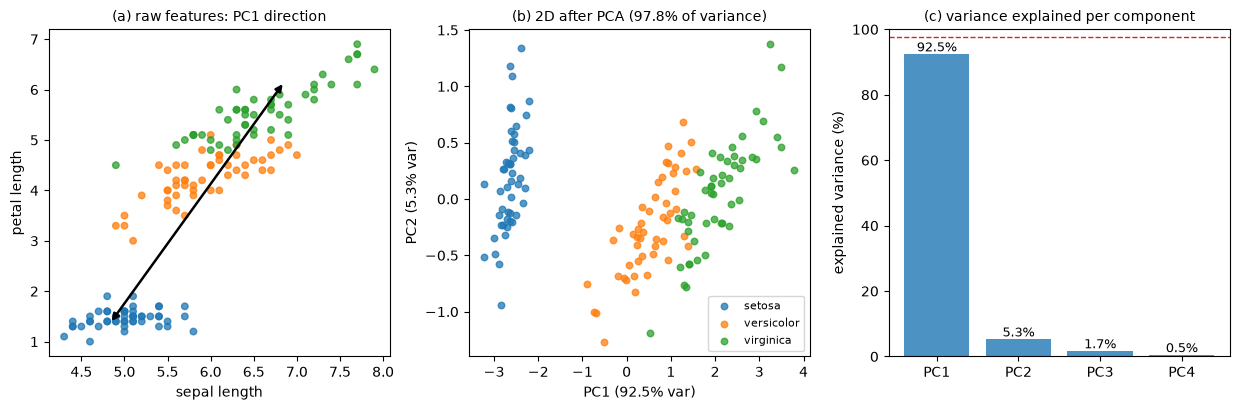

In [6]:
target = load_iris().target
cols = ["tab:blue", "tab:orange", "tab:green"]; names = ["setosa","versicolor","virginica"]
mu = X.mean(axis=0)
fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.2))

ax = axes[0]
ax.scatter(X[:,0], X[:,2], c=[cols[t] for t in target], s=22, alpha=0.75)
dd = np.array([evec[0,0], evec[2,0]]); dd = dd/np.linalg.norm(dd)  # 그림 축 2개만
ax.annotate("", xy=(mu[0]+dd[0]*2.6, mu[2]+dd[1]*2.6),
            xytext=(mu[0]-dd[0]*2.6, mu[2]-dd[1]*2.6),
            arrowprops=dict(arrowstyle="<|-|>", color="black", lw=1.8))
ax.set_xlabel("sepal length"); ax.set_ylabel("petal length")
ax.set_title("(a) raw features: PC1 direction", fontsize=10)

ax = axes[1]
for t in range(3):
    ax.scatter(X2[target==t,0], X2[target==t,1], c=cols[t], s=22, alpha=0.75, label=names[t])
ax.set_xlabel(f"PC1 ({ev[0]/ev.sum()*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({ev[1]/ev.sum()*100:.1f}% var)")
ax.set_title("(b) 2D after PCA (97.8% of variance)", fontsize=10); ax.legend(fontsize=8)

ax = axes[2]
ratios = ev/ev.sum()
ax.bar(["PC1","PC2","PC3","PC4"], ratios*100, color="tab:blue", alpha=0.8)
for i,r in enumerate(ratios): ax.text(i, r*100+0.8, f"{r*100:.1f}%", ha="center", fontsize=9)
ax.axhline(97.8, color="tab:red", ls="--", lw=1)
ax.set_ylabel("explained variance (%)"); ax.set_ylim(0,100)
ax.set_title("(c) variance explained per component", fontsize=10)

fig.tight_layout(); plt.show()


## 3. 자주 하는 실수: 표준화(스케일링) 없이 PCA를 돌리기

키(cm, 분산이 큼)와 몸무게(kg)처럼 **단위가 다른** 특징을 표준화 없이 PCA에
넣으면, 분산이 큰 축(키)에 PC1이 쏠린다. 같은 데이터를 표준화(각 컬럼을
평균 0·표준편차 1로)한 뒤 PCA를 하면 두 축을 동등하게 대우한다.


In [7]:
rng = np.random.RandomState(0)
h  = rng.normal(170, 8, 40)                  # 키 (cm)
wt = (h - 170) * 0.5 + rng.normal(0, 4, 40)   # 몸무게 (kg), 키와 상관 있음
raw = np.column_stack([h, wt])

# (1) 표준화 없이
wr, vr = np.linalg.eigh(np.cov(raw.T)); orr = np.argsort(wr)[::-1]
print("RAW    PC1 방향:", vr[:,orr[0]].round(3), " 1차원 설명분산:", round(wr[orr[0]]/wr.sum()*100,1), "%")

# (2) 표준화 후 (StandardScaler와 동일)
scaled = (raw - raw.mean(axis=0)) / raw.std(axis=0)
ws, vs = np.linalg.eigh(np.cov(scaled.T)); oss = np.argsort(ws)[::-1]
print("SCALED PC1 방향:", vs[:,oss[0]].round(3), " 1차원 설명분산:", round(ws[oss[0]]/ws.sum()*100,1), "%")


RAW    PC1 방향: [-0.851 -0.525]  1차원 설명분산: 92.7 %
SCALED PC1 방향: [-0.707 -0.707]  1차원 설명분산: 91.3 %


표준화 **없이**는 PC1이 키 축에 크게 쏠린 방향(약 \((-0.85,-0.53)\)),
표준화 **후**에는 두 축을 동등하게 대우한 45도 방향(약 \((\pm0.71,\pm0.71)\))으로
바뀐다(고유벡터의 부호는 구현에 따라 뒤집힐 수 있음 — 방향 자체가 중요하다).
**같은 데이터인데, 단위에 따라 주성분의 방향이 달라지는 것** — 이것이
"스케일링 없이 PCA"가 왜 위험한지다. 실무 규칙: PCA 전에는 항상
`StandardScaler`로 정규화.


## 4. 몇 차원을 남길 것인가: 스크리 플롯

누적 설명 분산 비율을 그려 "90/95% 기준"을 넘는 지점을 찾는다.


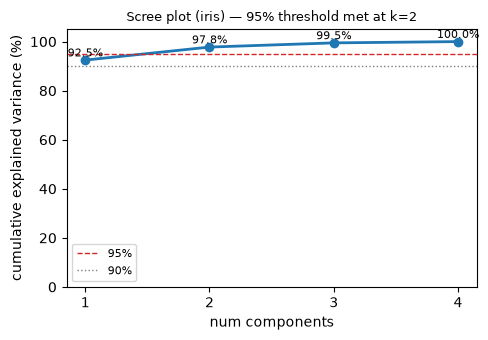

In [8]:
ks = np.arange(1, 5)
cum = np.cumsum(ev/ev.sum())
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(ks, cum*100, "o-", lw=2)
ax.axhline(95, color="tab:red", ls="--", lw=1, label="95%")
ax.axhline(90, color="tab:gray", ls=":", lw=1, label="90%")
for k, c in zip(ks, cum):
    ax.text(k, c*100+1.5, f"{c*100:.1f}%", ha="center", fontsize=8)
ax.set_xticks(ks); ax.set_ylim(0, 105); ax.legend(fontsize=8)
ax.set_xlabel("num components"); ax.set_ylabel("cumulative explained variance (%)")
ax.set_title("Scree plot (iris) — 95% threshold met at k=2", fontsize=9)
fig.tight_layout(); plt.show()


누적이 **95%를 넘는 가장 작은 \(k\)는 2** — "95% 기준"을 쓰면 붓꽃을
2차원으로 줄여도 97.8%의 분산을 보존한다. 이것이 본문 FAQ의 "몇 개의
주성분을 남길 것인가"에 대한 실용적 판단법이다.
